# 01 · EDA: lluvia y mortalidad en carreteras del Perú

**Pregunta:** ¿cuánta mortalidad hay en una carretera según el nivel de precipitación?

Flujo: datos SUTRAN → limpieza → ubicación por vía y km → lluvia en el punto (Open-Meteo) → EDA. La preparación está en `src/preprocessing.py`; aquí se llama a esas funciones y se anotan las **decisiones** y los **hallazgos**.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

# Raíz del repo (funciona si el notebook se ejecuta desde /notebooks o desde la raíz)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import preprocessing as pp

PLOTS = ROOT / "results" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

## 1. Datos de accidentes (SUTRAN)

**Decisión:** leer todo como texto (`dtype=str`), porque los faltantes vienen como `"N.I."` y no como celdas vacías.

In [2]:
raw = pp.leer_accidentes()
print(f"{raw.shape[0]:,} accidentes × {raw.shape[1]} columnas")
raw.head()

8,155 accidentes × 9 columnas


,FECHA_CORTE,FECHA,HORA,DEPARTAMENTO,CODIGO_VIA,KILOMETRO,MODALIDAD,NUM_FALLECIDOS,NUM_HERIDOS
0,20211222,20200101,05:40,LIMA,PE-1S,24,DESPISTE,0,0
1,20211222,20200101,16:30,CAJAMARCA,PE-3N,74,DESPISTE,0,0
2,20211222,20200101,07:45,PASCO,PE-3N,103,DESPISTE,0,1
3,20211222,20200101,18:30,CAJAMARCA,PE-08,111,DESPISTE,0,2
4,20211222,20200101,18:40,LIMA,PE-1N,174,DESPISTE,0,5


### 1.1 Calidad del archivo crudo

In [3]:
display(pp.resumen_faltantes(raw))
print("FECHA_CORTE (valores distintos):", raw["FECHA_CORTE"].unique().tolist())
print("Rango de FECHA:", raw["FECHA"].min(), "→", raw["FECHA"].max())
print("Modalidades:", sorted(raw["MODALIDAD"].unique()))
print("\nDepartamentos tal como vienen en el crudo:")
print(raw["DEPARTAMENTO"].value_counts().to_string())

,vacios,N.I.,% faltante
FECHA_CORTE,0,0,0.00
FECHA,0,0,0.00
HORA,0,88,1.08
DEPARTAMENTO,0,7,0.09
CODIGO_VIA,0,46,0.56
KILOMETRO,0,45,0.55
MODALIDAD,0,28,0.34
NUM_FALLECIDOS,0,3,0.04
NUM_HERIDOS,0,10,0.12


FECHA_CORTE (valores distintos): ['20211222']
Rango de FECHA: 20200101 → 20210930
Modalidades: ['ATROPELLO', 'CHOQUE', 'DESPISTE', 'ESPECIAL', 'N.I.', 'VOLCADURA']

Departamentos tal como vienen en el crudo:
DEPARTAMENTO
LIMA             1558
AREQUIPA          795
JUNIN             715
ANCASH            602
PUNO              529
ICA               377
CAJAMARCA         350
CUSCO             346
LAMBAYEQUE        343
LA LIBERTAD       329
PIURA             327
SAN MARTIN        274
APURIMAC          202
MADRE DE DIOS     191
HUANUCO           174
AYACUCHO          168
MOQUEGUA          155
UCAYALI           154
AMAZONAS          152
TACNA             151
LORETO             82
PASCO              77
HUANCAVELICA       62
TUMBES             25
N.I.                7
CALLAO              6
Arequipa            2
Puno                1
Cusco               1


**Hallazgos**
- Faltantes ≤ 1.1 % por columna; `NUM_FALLECIDOS` solo falta en 3.
- Periodo real: enero 2020 – septiembre 2021 (la `FECHA_CORTE` es posterior).
- Departamentos escritos de dos formas (`AREQUIPA` / `Arequipa`): hay que normalizar.

### 1.2 Limpieza

| Problema | Decisión | Por qué |
|---|---|---|
| `NUM_FALLECIDOS` = N.I. (3) | Descartar | Es la variable objetivo. |
| `DEPARTAMENTO` = N.I. (7) | Descartar | Sin él no se asigna clima. |
| Duplicados exactos (35) | Descartar | Doble registro; duplicaría fallecidos. |
| `HORA`, `CODIGO_VIA`, `KILOMETRO`, `MODALIDAD` = N.I. | Conservar | La lluvia es diaria; no son necesarias para el cruce. |
| `NUM_HERIDOS` = N.I. (10) | 0 | Solo se usa en el EDA. |
| Tildes y mayúsculas | Normalizar | Unificar departamentos. |

Se derivan `HORA_INT`, `ANIO`, `MES`, `DIA_SEMANA` y el objetivo `ES_FATAL` (≥ 1 fallecido).

In [4]:
df, bitacora = pp.limpiar_accidentes(raw)
display(bitacora)

print(f"Registros finales: {len(df):,} ({100 * len(df) / len(raw):.1f} % del crudo)")
print("Periodo:", df.FECHA.min().date(), "→", df.FECHA.max().date())
print("Departamentos tras normalizar:", df.DEPARTAMENTO.nunique())
print("\nFaltantes que se conservan:")
print(f"  hora N.I.:      {df.HORA_INT.isna().sum()}")
print(f"  vía N.I.:       {(df.CODIGO_VIA == pp.NI).sum()}")
print(f"  kilómetro N.I.: {df.KILOMETRO.isna().sum()}")
print(f"  modalidad N.I.: {(df.MODALIDAD == pp.NI).sum()}")

,paso,antes,descartados,despues,decision
0,Fecha inválida o sin dato de fallecidos,8155,3,8152,Descartar: sin variable objetivo
1,Departamento 'N.I.',8152,7,8145,Descartar: no se puede asignar lluvia
2,Duplicados exactos,8145,35,8110,Descartar: mismo registro repetido


Registros finales: 8,110 (99.4 % del crudo)
Periodo: 2020-01-01 → 2021-09-30
Departamentos tras normalizar: 25

Faltantes que se conservan:
  hora N.I.:      86
  vía N.I.:       39
  kilómetro N.I.: 43
  modalidad N.I.: 26


In [5]:
# Ejemplos de duplicados exactos en el crudo: cada par es idéntico en todas las columnas
dups = raw[raw.duplicated(keep=False)].sort_values(["FECHA", "HORA", "CODIGO_VIA"])
print(f"Filas involucradas: {len(dups)} ({raw.duplicated().sum()} sobrantes)")
dups.head(6)

Filas involucradas: 70 (35 sobrantes)


,FECHA_CORTE,FECHA,HORA,DEPARTAMENTO,CODIGO_VIA,KILOMETRO,MODALIDAD,NUM_FALLECIDOS,NUM_HERIDOS
219,20211222,20200115,17:40,JUNIN,PE-3S,62,DESPISTE,0,1
220,20211222,20200115,17:40,JUNIN,PE-3S,62,DESPISTE,0,1
279,20211222,20200118,12:30,PUNO,PE-34A,272,DESPISTE,0,0
280,20211222,20200118,12:30,PUNO,PE-34A,272,DESPISTE,0,0
439,20211222,20200128,04:00,JUNIN,PE-3S,74,DESPISTE,0,0
440,20211222,20200128,04:00,JUNIN,PE-3S,74,DESPISTE,0,0


Quedan **8 110 accidentes** (−0.6 %).

### 1.3 Valores extremos

In [6]:
print("Distribución de fallecidos por accidente:")
print(df.NUM_FALLECIDOS.value_counts().sort_index().to_string())
print("\nAccidentes con 10 o más fallecidos:")
df.loc[df.NUM_FALLECIDOS >= 10, ["FECHA", "HORA", "DEPARTAMENTO", "CODIGO_VIA", "KILOMETRO", "MODALIDAD",
                                  "NUM_FALLECIDOS", "NUM_HERIDOS"]]

Distribución de fallecidos por accidente:
NUM_FALLECIDOS
0     7159
1      775
2      111
3       30
4       12
5        7
6        4
7        2
9        1
11       3
16       2
18       1
20       1
22       1
33       1

Accidentes con 10 o más fallecidos:


,FECHA,HORA,DEPARTAMENTO,CODIGO_VIA,KILOMETRO,MODALIDAD,NUM_FALLECIDOS,NUM_HERIDOS
91,2020-01-06,00:20,AREQUIPA,PE-1S,571.0,CHOQUE,16,46.0
2000,2020-07-26,17:00,LA LIBERTAD,LI-122,86.0,DESPISTE,11,2.0
3730,2020-12-14,16:30,PUNO,PE-34A,192.0,CHOQUE,11,12.0
5349,2021-04-08,07:25,AYACUCHO,PE-30A,238.0,DESPISTE,11,21.0
5397,2021-04-12,07:00,ANCASH,PE-14C,49.0,DESPISTE,20,17.0
6214,2021-06-08,12:40,LA LIBERTAD,LI-127,0.0,DESPISTE,18,5.0
6362,2021-06-18,03:30,AYACUCHO,PE-30A,40.0,DESPISTE,22,17.0
7528,2021-08-27,12:30,APURIMAC,PE-3SF,350.0,DESPISTE,16,2.0
7606,2021-08-31,04:15,LIMA,PE-22,72.0,DESPISTE,33,29.0


**Decisión:** conservar los 9 accidentes con ≥ 10 fallecidos: son reales (despistes y choques con muchos heridos) y son los casos más graves. Su efecto se revisa en 4.3.

In [7]:
# KILOMETRO es la distancia desde el inicio de CADA vía, no una coordenada
km = df.groupby("CODIGO_VIA").KILOMETRO.agg(accidentes="count", km_min="min", km_max="max")
print(df.KILOMETRO.describe().round(1).to_string())
km.sort_values("km_max", ascending=False).head(6)

count    8067.0
mean      291.0
std       336.7
min         0.0
25%        56.0
50%       139.0
75%       411.0
max      1814.0


,accidentes,km_min,km_max
CODIGO_VIA,,,
PE-3N,471,0.0,1814.0
PE-1S,1400,0.0,1497.0
PE-3S,634,0.0,1495.0
PE-5N,435,0.0,1492.0
PE-3SA,49,1.0,1430.0
PE-1NJ,142,1.0,1338.0


El kilómetro solo tiene sentido dentro de cada vía. **Decisión:** no usarlo solo; en la sección 2 se convierte en coordenadas.

## 2. Ubicación: vía + kilómetro → coordenadas

**Decisiones**
- **Fuente:** Red Vial Nacional del MTC (2014): cada tramo trae ruta, km inicial y final, y departamento.
- **Método:** interpolar el kilómetro a lo largo del tramo (la longitud de los tramos coincide con su kilometraje, mediana 0.99). Se corrigen los tramos dibujados al revés.
- **Validación:** el punto solo se acepta si cae en el departamento del accidente (o a ≤ 10 km de su límite).
- **Respaldo:** si no, la capital del departamento. La columna `UBICACION` (`km` / `capital`) indica cuál se usó.

In [8]:
tramos = pp.cargar_red_vial()
print(f"Red vial: {len(tramos):,} tramos de {len({t['ruta'] for t in tramos})} rutas nacionales")

df = df.join(pp.ubicar_accidentes(df, tramos))
motivos = (df.groupby(["UBICACION", "MOTIVO_UBICACION"]).size().rename("accidentes").reset_index()
           .sort_values(["UBICACION", "accidentes"], ascending=[False, False]))
motivos["%"] = (100 * motivos.accidentes / len(df)).round(1)
display(motivos)
print(df.UBICACION.value_counts(normalize=True).mul(100).round(1).to_string())

Red vial: 3,465 tramos de 141 rutas nacionales


,UBICACION,MOTIVO_UBICACION,accidentes,%
6,km,tramo en el departamento,6411,79.1
7,km,tramo en el departamento vecino (frontera),91,1.1
3,capital,tramo en otro departamento (km no coincide con...,1059,13.1
5,capital,vía departamental o vecinal,229,2.8
1,capital,kilómetro fuera de los tramos de la ruta,228,2.8
4,capital,vía N.I.,39,0.5
0,capital,kilómetro N.I.,35,0.4
2,capital,ruta no está en la capa del MTC,18,0.2


UBICACION
km         80.2
capital    19.8


**Hallazgo:** **80.2 %** ubicado por km. Del resto, 1 059 tienen un km que no coincide con el kilometraje del MTC (hitos antiguos), 229 están en vías departamentales y el resto no tiene vía o km válidos.

Distancia del punto ubicado a la capital de su departamento (km):
count    6502.0
mean       81.4
std        60.4
min         0.2
25%        40.7
50%        72.9
75%       104.2
90%       142.9
max       385.9

Mediana por departamento (km):
DEPARTAMENTO
SAN MARTIN       243.0
JUNIN            101.0
ANCASH            90.0
MADRE DE DIOS     88.0
CUSCO             83.0
LIMA              79.0
AREQUIPA          75.0
PUNO              75.0


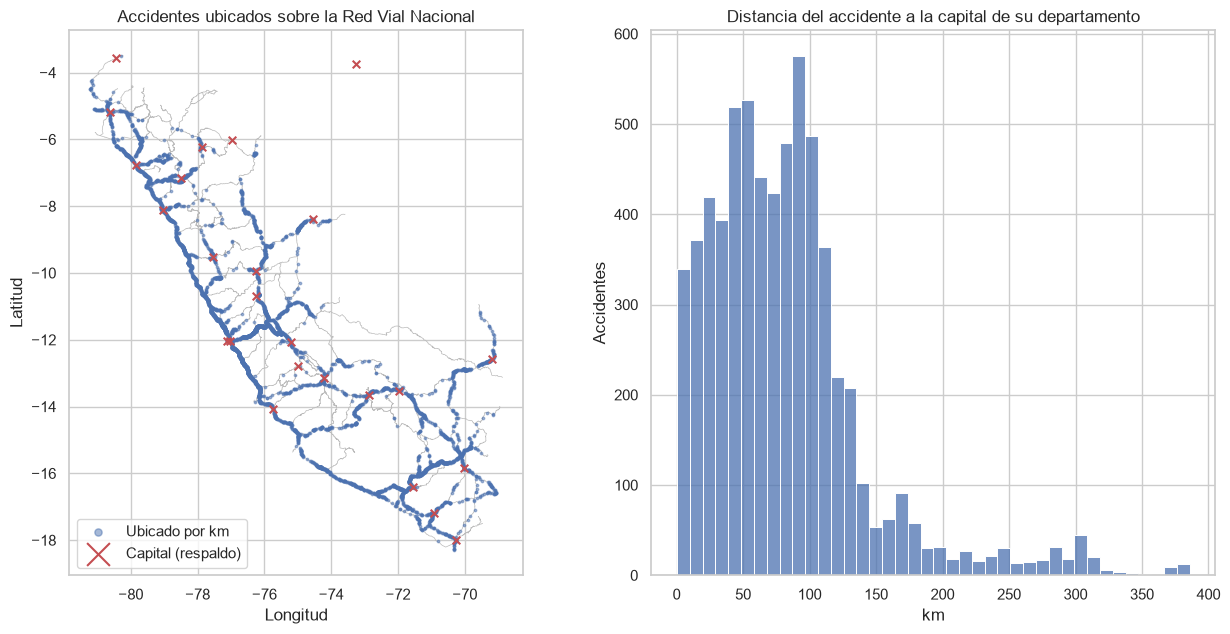

In [9]:
cap = np.array([pp.COORD[dep] for dep in df.DEPARTAMENTO])
df["DIST_CAPITAL_KM"] = pp.haversine_km(cap[:, 1], cap[:, 0], df.LON, df.LAT)
km_ok = df.UBICACION == "km"
print("Distancia del punto ubicado a la capital de su departamento (km):")
print(df.loc[km_ok, "DIST_CAPITAL_KM"].describe(percentiles=[.25, .5, .75, .9]).round(1).to_string())
print("\nMediana por departamento (km):")
print(df[km_ok].groupby("DEPARTAMENTO").DIST_CAPITAL_KM.median().round(0).sort_values(ascending=False).head(8).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5), gridspec_kw={"width_ratios": [1.1, 1]})
for t in tramos:
    ax[0].plot(t["lon"], t["lat"], color="#BBBBBB", lw=0.5, zorder=1)
ax[0].scatter(df.loc[km_ok, "LON"], df.loc[km_ok, "LAT"], s=3, color="#4C72B0", alpha=.5, label="Ubicado por km", zorder=2)
caps = np.array(list(pp.COORD.values()))
ax[0].scatter(caps[:, 1], caps[:, 0], marker="x", s=30, color="#C44E52", label="Capital (respaldo)", zorder=3)
ax[0].set(title="Accidentes ubicados sobre la Red Vial Nacional", xlabel="Longitud", ylabel="Latitud", aspect="equal")
ax[0].legend(loc="lower left", markerscale=3)
sns.histplot(df.loc[km_ok, "DIST_CAPITAL_KM"], bins=40, ax=ax[1], color="#4C72B0")
ax[1].set(title="Distancia del accidente a la capital de su departamento", xlabel="km", ylabel="Accidentes")
plt.tight_layout(); plt.savefig(PLOTS / "eda_09_ubicacion.png", dpi=150); plt.show()

**Hallazgo:** en mediana el accidente está a **73 km** de su capital (p90: 143 km). Ej.: el accidente de 33 fallecidos queda en la Carretera Central a ~3 800 m, no en Lima.

## 3. Clima: precipitación diaria (Open-Meteo)

**Decisiones**
- Reanálisis de Open-Meteo (no estaciones) en la **celda de 0.1° (~11 km)** del accidente, que es la resolución real del modelo.
- Solo se piden los bloques de 14 días con accidentes en cada celda (límite gratuito de la API). Queda en caché en `data/raw/`.
- `timezone=America/Lima` para que el día coincida con `FECHA`.
- Se guarda también `ELEVACION` de la celda y la lluvia de la capital (`PRECIP_CAPITAL`) para comparar.

In [10]:
df["CELDA_LAT"], df["CELDA_LON"] = pp.asignar_celda(df.LAT, df.LON)
clima_cap = pp.cargar_clima(df)
clima = pp.cargar_clima_puntos(df)
print(f"Celdas con accidentes: {df[['CELDA_LAT', 'CELDA_LON']].drop_duplicates().shape[0]}")
print(f"Clima por celda: {len(clima):,} filas (celda-día) | {clima.FECHA.min().date()} → {clima.FECHA.max().date()}")
print(f"Clima de capitales: {len(clima_cap):,} filas | {clima_cap.DEPARTAMENTO.nunique()} departamentos")
clima[["precipitation_sum", "rain_sum", "precipitation_hours", "ELEVACION"]].describe().round(2)

Celdas con accidentes: 964
Clima por celda: 81,128 filas (celda-día) | 2020-01-01 → 2021-09-30
Clima de capitales: 15,975 filas | 25 departamentos


,precipitation_sum,rain_sum,precipitation_hours,ELEVACION
count,81128.00,81128.00,81128.00,81128.00
mean,2.01,1.89,3.86,1671.60
std,4.95,4.83,5.64,1700.25
min,0.00,0.00,0.00,-1.00
25%,0.00,0.00,0.00,134.00
50%,0.00,0.00,0.00,749.00
75%,1.70,1.50,6.00,3598.00
max,163.90,163.90,24.00,5013.00


In [11]:
# ¿precipitation_sum o rain_sum?
dif = clima.precipitation_sum - clima.rain_sum
print(f"Correlación precipitation_sum vs. rain_sum: {clima[['precipitation_sum', 'rain_sum']].corr().iloc[0, 1]:.4f}")
print(f"Celda-días en que difieren: {(dif > 0).sum()} ({100 * (dif > 0).mean():.2f} %)")
print(f"Altitud mediana de esas celdas: {clima.loc[dif > 0, 'ELEVACION'].median():.0f} m "
      f"(resto: {clima.loc[dif == 0, 'ELEVACION'].median():.0f} m)")
print("Valores distintos de cero más pequeños de precipitation_sum:",
      np.sort(clima.loc[clima.precipitation_sum > 0, "precipitation_sum"].unique())[:3])

Correlación precipitation_sum vs. rain_sum: 0.9890
Celda-días en que difieren: 5974 (7.36 %)
Altitud mediana de esas celdas: 4343 m (resto: 564 m)
Valores distintos de cero más pequeños de precipitation_sum: [0.1 0.2 0.3]


**Decisión:** usar `precipitation_sum` (correlación 0.989 con `rain_sum`); la diferencia es nieve o granizo en la puna, que también afecta la vía.

In [12]:
data = df.merge(clima_cap[["DEPARTAMENTO", "FECHA", "precipitation_sum"]].rename(columns={"precipitation_sum": "PRECIP_CAPITAL"}),
                on=["DEPARTAMENTO", "FECHA"], how="left")
data = data.merge(clima, on=["CELDA_LAT", "CELDA_LON", "FECHA"], how="left")
assert len(data) == len(df), "La unión no debe duplicar ni perder accidentes"
print(f"Accidentes con lluvia en su celda: {data.precipitation_sum.notna().mean():.1%} | "
      f"con lluvia de la capital: {data.PRECIP_CAPITAL.notna().mean():.1%}")

pp.PROC.mkdir(parents=True, exist_ok=True)
data.drop(columns="DIST_CAPITAL_KM").to_csv(pp.F_DATASET, index=False)
print("Guardado:", pp.F_DATASET.relative_to(ROOT), data.drop(columns="DIST_CAPITAL_KM").shape)

Accidentes con lluvia en su celda: 100.0% | con lluvia de la capital: 100.0%
Guardado: data\processed\accidentes_clima.csv (8110, 25)


**¿Cuánto cambia frente a la lluvia de la capital?**

Correlación lluvia en el punto vs. en la capital: 0.543
Diferencia absoluta (mm): mediana 0.20, p90 5.70


precipitation_sum,llueve en el punto,seco en el punto
PRECIP_CAPITAL,,
llueve en la capital,32.3,8.9
seco en la capital,13.5,45.3


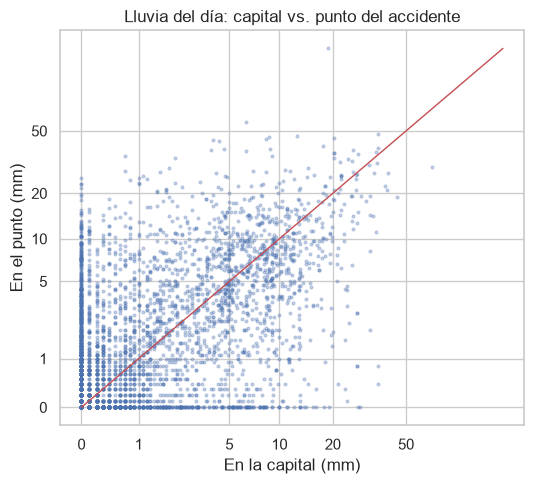

In [13]:
k = data[data.UBICACION == "km"]
llueve_punto, llueve_cap = k.precipitation_sum > 0.1, k.PRECIP_CAPITAL > 0.1
print(f"Correlación lluvia en el punto vs. en la capital: {k[['precipitation_sum', 'PRECIP_CAPITAL']].corr().iloc[0, 1]:.3f}")
print(f"Diferencia absoluta (mm): mediana {(k.precipitation_sum - k.PRECIP_CAPITAL).abs().median():.2f}, "
      f"p90 {(k.precipitation_sum - k.PRECIP_CAPITAL).abs().quantile(.9):.2f}")
display(pd.crosstab(llueve_cap.map({True: "llueve en la capital", False: "seco en la capital"}),
                    llueve_punto.map({True: "llueve en el punto", False: "seco en el punto"}), normalize="all").mul(100).round(1))

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(np.log1p(k.PRECIP_CAPITAL), np.log1p(k.precipitation_sum), s=4, alpha=.3, color="#4C72B0")
lim = np.log1p(max(k.PRECIP_CAPITAL.max(), k.precipitation_sum.max()))
ax.plot([0, lim], [0, lim], color="#C44E52", lw=1)
ticks = [0, 1, 5, 10, 20, 50]
ax.set_xticks(np.log1p(ticks)); ax.set_xticklabels(ticks); ax.set_yticks(np.log1p(ticks)); ax.set_yticklabels(ticks)
ax.set(title="Lluvia del día: capital vs. punto del accidente", xlabel="En la capital (mm)", ylabel="En el punto (mm)")
plt.tight_layout(); plt.savefig(PLOTS / "eda_10_lluvia_punto_vs_capital.png", dpi=150); plt.show()

**Hallazgo:** la capital era un mal *proxy*: correlación **0.54** con la lluvia en el punto, y en el **22 %** de los accidentes no coinciden en si llovió.

## 4. Análisis exploratorio

### 4.1 Panorama

Accidentes                                      8110.000
Fallecidos totales                              1375.000
Heridos totales                                10635.000
% de accidentes con ≥1 fallecido                  11.726
Fallecidos por accidente (promedio)                0.170
Varianza de fallecidos por accidente               0.631
Máx. fallecidos en un accidente                   33.000
% de accidentes en día con lluvia (>0 mm)         51.591
% de accidentes en día con lluvia (>0.1 mm)       47.583
% de accidentes ubicados por km                   80.173


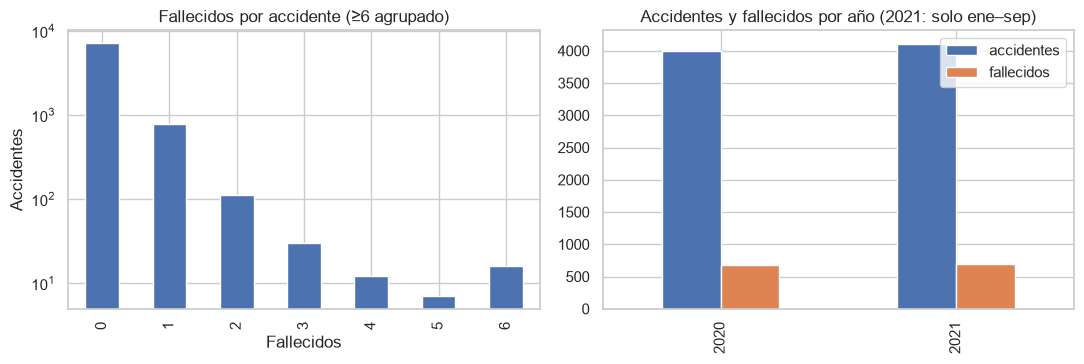

In [14]:
d = data.copy()

resumen = pd.Series({
    "Accidentes": len(d),
    "Fallecidos totales": d.NUM_FALLECIDOS.sum(),
    "Heridos totales": d.NUM_HERIDOS.sum(),
    "% de accidentes con ≥1 fallecido": 100 * d.ES_FATAL.mean(),
    "Fallecidos por accidente (promedio)": d.NUM_FALLECIDOS.mean(),
    "Varianza de fallecidos por accidente": d.NUM_FALLECIDOS.var(),
    "Máx. fallecidos en un accidente": d.NUM_FALLECIDOS.max(),
    "% de accidentes en día con lluvia (>0 mm)": 100 * (d.precipitation_sum > 0).mean(),
    "% de accidentes en día con lluvia (>0.1 mm)": 100 * (d.precipitation_sum > 0.1).mean(),
    "% de accidentes ubicados por km": 100 * (d.UBICACION == "km").mean(),
}).round(3)
print(resumen.to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
d.NUM_FALLECIDOS.clip(upper=6).value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set(title="Fallecidos por accidente (≥6 agrupado)", xlabel="Fallecidos", ylabel="Accidentes")
ax[0].set_yscale("log")
d.groupby("ANIO").agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum")).plot.bar(ax=ax[1])
ax[1].set(title="Accidentes y fallecidos por año (2021: solo ene–sep)", xlabel="")
plt.tight_layout(); plt.savefig(PLOTS / "eda_01_panorama.png", dpi=150); plt.show()

**Hallazgos → modelado**
- **11.7 %** de accidentes fatales: clase desbalanceada → PR-AUC y `class_weight="balanced"`.
- Fallecidos con sobredispersión (varianza 0.63 > media 0.17) → Poisson como baseline, binomial negativa propuesta.
- 51.6 % de los accidentes ocurrió con lluvia > 0 mm.

### 4.2 Departamento, modalidad, hora y estacionalidad

**Decisión:** tasa por departamento solo con ≥ 50 accidentes.

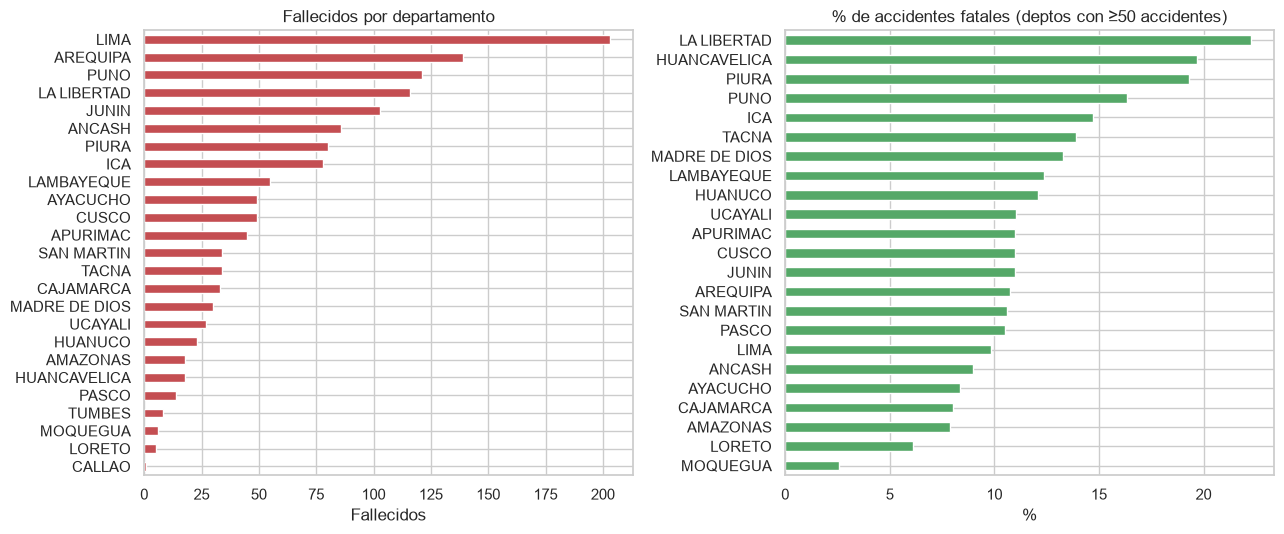

,accidentes,fallecidos,pct_fatal
MODALIDAD,,,
ATROPELLO,361,160,42.94
N.I.,26,5,19.23
CHOQUE,3605,669,13.59
ESPECIAL,186,20,8.06
DESPISTE,3804,513,7.36
VOLCADURA,128,8,4.69


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
dep = d.groupby("DEPARTAMENTO").agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum"),
                                    tasa_fatal=("ES_FATAL", "mean")).sort_values("fallecidos")
dep["fallecidos"].plot.barh(ax=ax[0], color="#C44E52")
ax[0].set(title="Fallecidos por departamento", xlabel="Fallecidos", ylabel="")
dep.query("accidentes >= 50")["tasa_fatal"].sort_values().mul(100).plot.barh(ax=ax[1], color="#55A868")
ax[1].set(title="% de accidentes fatales (deptos con ≥50 accidentes)", xlabel="%", ylabel="")
plt.tight_layout(); plt.savefig(PLOTS / "eda_02_departamentos.png", dpi=150); plt.show()

mod = d.groupby("MODALIDAD").agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum"),
                                 pct_fatal=("ES_FATAL", lambda x: 100 * x.mean())).round(2)
mod.sort_values("pct_fatal", ascending=False)

**Hallazgos:** Lima tiene más fallecidos por volumen, pero los más letales son La Libertad, Huancavelica, Piura y Puno. La **modalidad** es la variable más ligada a la fatalidad (atropello 42.9 % vs. despiste 7.4 %), pero se conoce después del accidente → va en un conjunto aparte (Set B).

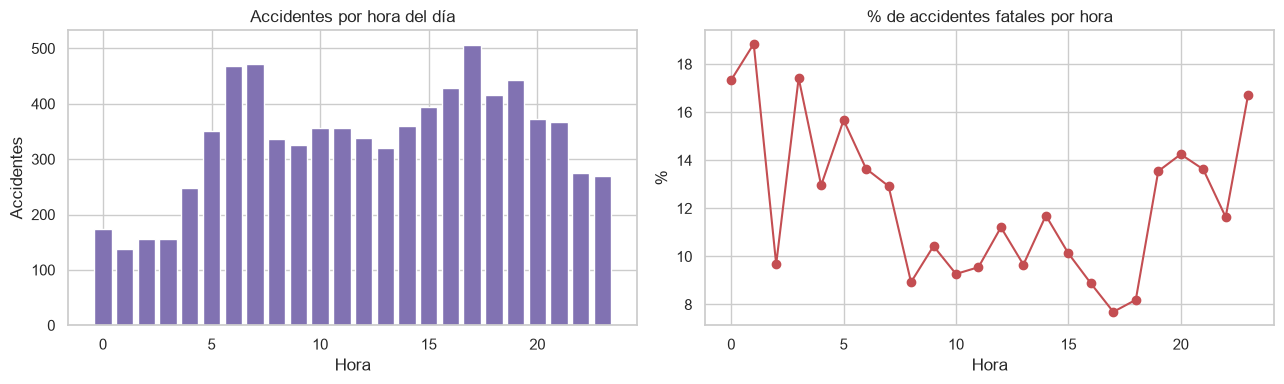

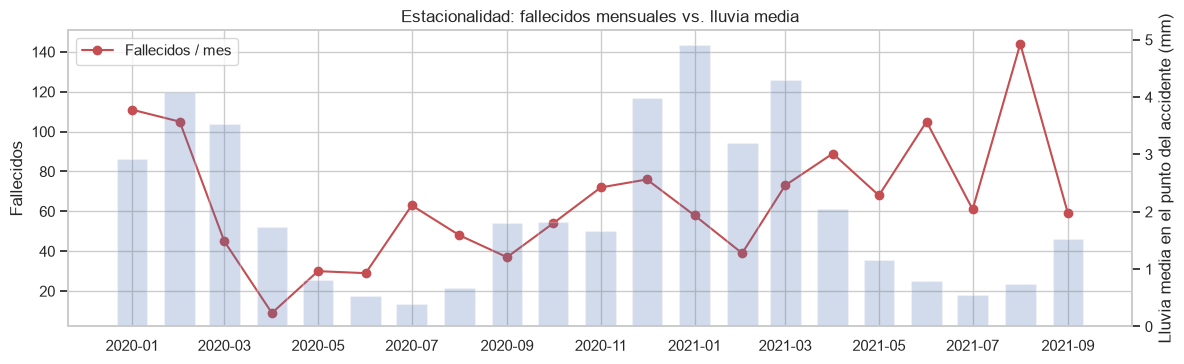

In [16]:
# Los 86 accidentes sin hora se excluyen SOLO de estos gráficos
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
h = d.dropna(subset=["HORA_INT"]).groupby("HORA_INT").agg(n=("ES_FATAL", "size"), tasa=("ES_FATAL", "mean"))
ax[0].bar(h.index, h["n"], color="#8172B2"); ax[0].set(title="Accidentes por hora del día", xlabel="Hora", ylabel="Accidentes")
ax[1].plot(h.index, 100 * h["tasa"], marker="o", color="#C44E52")
ax[1].set(title="% de accidentes fatales por hora", xlabel="Hora", ylabel="%")
plt.tight_layout(); plt.savefig(PLOTS / "eda_03_hora.png", dpi=150); plt.show()

m = d.groupby(["ANIO", "MES"]).agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum"),
                                   lluvia_media=("precipitation_sum", "mean")).reset_index()
m["periodo"] = pd.to_datetime(dict(year=m.ANIO, month=m.MES, day=1))
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(m.periodo, m.fallecidos, marker="o", label="Fallecidos / mes", color="#C44E52")
ax.set_ylabel("Fallecidos")
ax2 = ax.twinx(); ax2.bar(m.periodo, m.lluvia_media, width=20, alpha=.25, color="#4C72B0")
ax2.set_ylabel("Lluvia media en el punto del accidente (mm)"); ax2.grid(False)
ax.set_title("Estacionalidad: fallecidos mensuales vs. lluvia media"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig(PLOTS / "eda_04_estacionalidad.png", dpi=150); plt.show()

**Hallazgos:** la madrugada es la más letal (≈ 17–19 % fatal, 0–3 h). La lluvia se concentra en dic–mar y no coincide con los picos de fallecidos; la cuarentena (abril 2020) muestra que la movilidad confunde. **Decisión:** hora y mes con seno/coseno.

### 4.3 Lluvia vs. mortalidad

**Decisiones:** rangos fijos de lluvia (0, 0–1, 1–5, 5–10, 10–20, > 20 mm), porque más de la mitad son 0 y los cuantiles se repetirían; IC de Wilson para el % fatal; pruebas no paramétricas (chi², Spearman, Mann-Whitney) porque nada es normal.

count    8110.00
mean        2.18
std         4.99
min         0.00
25%         0.00
50%         0.10
75%         2.10
max       163.90


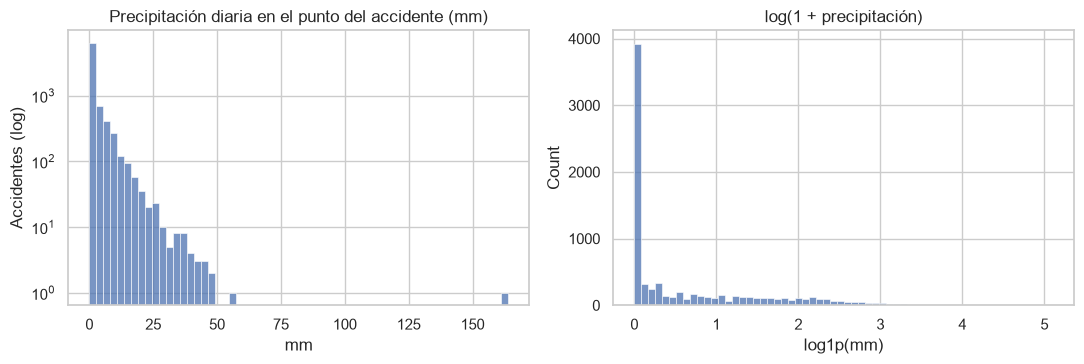

In [17]:
print(d.precipitation_sum.describe().round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(d.precipitation_sum, bins=60, ax=ax[0], color="#4C72B0"); ax[0].set_yscale("log")
ax[0].set(title="Precipitación diaria en el punto del accidente (mm)", xlabel="mm", ylabel="Accidentes (log)")
sns.histplot(np.log1p(d.precipitation_sum), bins=60, ax=ax[1], color="#4C72B0")
ax[1].set(title="log(1 + precipitación)", xlabel="log1p(mm)")
plt.tight_layout(); plt.savefig(PLOTS / "eda_05_precipitacion.png", dpi=150); plt.show()

,accidentes,fatales,fallecidos,pct_fatal,fallecidos_por_accidente,ic95_inf,ic95_sup
PRECIP_BIN,,,,,,,
0 mm,3926,500,700,12.736,0.178,11.729,13.815
0–1,1551,183,296,11.799,0.191,10.287,13.500
1–5,1491,143,211,9.591,0.142,8.198,11.191
5–10,673,76,102,11.293,0.152,9.118,13.907
10–20,362,32,43,8.840,0.119,6.331,12.213
>20,107,17,23,15.888,0.215,10.163,23.978


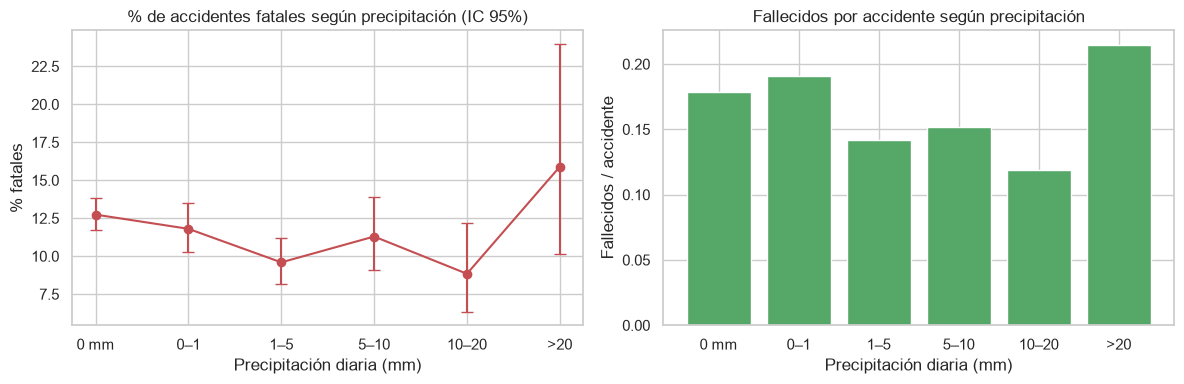

In [18]:
BINS = [-1, 0, 1, 5, 10, 20, np.inf]
ETIQ = ["0 mm", "0–1", "1–5", "5–10", "10–20", ">20"]
d["PRECIP_BIN"] = pd.cut(d.precipitation_sum, bins=BINS, labels=ETIQ)   # (0, 1], (1, 5], ...


def wilson(k, n, z=1.96):
    p = k / n
    den = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return c - h, c + h


t = d.groupby("PRECIP_BIN", observed=True).agg(accidentes=("ES_FATAL", "size"), fatales=("ES_FATAL", "sum"),
                                              fallecidos=("NUM_FALLECIDOS", "sum"))
t["pct_fatal"] = 100 * t.fatales / t.accidentes
t["fallecidos_por_accidente"] = t.fallecidos / t.accidentes
lo, hi = wilson(t.fatales.values, t.accidentes.values)
t["ic95_inf"], t["ic95_sup"] = 100 * lo, 100 * hi
display(t.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(t))
ax[0].errorbar(x, t.pct_fatal, yerr=[t.pct_fatal - t.ic95_inf, t.ic95_sup - t.pct_fatal], fmt="o-", capsize=4, color="#C44E52")
ax[0].set_xticks(x); ax[0].set_xticklabels(t.index)
ax[0].set(title="% de accidentes fatales según precipitación (IC 95%)", xlabel="Precipitación diaria (mm)", ylabel="% fatales")
ax[1].bar(x, t.fallecidos_por_accidente, color="#55A868")
ax[1].set_xticks(x); ax[1].set_xticklabels(t.index)
ax[1].set(title="Fallecidos por accidente según precipitación", xlabel="Precipitación diaria (mm)", ylabel="Fallecidos / accidente")
plt.tight_layout(); plt.savefig(PLOTS / "eda_06_lluvia_vs_fatalidad.png", dpi=150); plt.show()

**Pruebas** (asociación bruta, sin controles).

In [19]:
tabla = pd.crosstab(d.PRECIP_BIN, d.ES_FATAL)
chi2, p_chi, _, _ = stats.chi2_contingency(tabla)
rho, p_rho = stats.spearmanr(d.precipitation_sum, d.NUM_FALLECIDOS)
u, p_u = stats.mannwhitneyu(d.loc[d.ES_FATAL == 1, "precipitation_sum"],
                            d.loc[d.ES_FATAL == 0, "precipitation_sum"])
print(f"Chi² (rangos de lluvia × fatal): chi2={chi2:.2f}, p={p_chi:.4g}")
print(f"Spearman (lluvia vs. fallecidos): rho={rho:.4f}, p={p_rho:.4g}")
print(f"Mann-Whitney (lluvia en accidentes fatales vs. no fatales): p={p_u:.4g}")

Chi² (rangos de lluvia × fatal): chi2=15.27, p=0.009283
Spearman (lluvia vs. fallecidos): rho=-0.0313, p=0.004856
Mann-Whitney (lluvia en accidentes fatales vs. no fatales): p=0.005367


**Hallazgo:** asociación **negativa y muy débil** (Spearman ρ = −0.031, p = 0.005): con más lluvia, los accidentes son apenas *menos* fatales, al revés de la hipótesis.

In [20]:
extremo = d.NUM_FALLECIDOS >= 10
sens = pd.DataFrame({
    "accidentes": d.groupby("PRECIP_BIN", observed=True).size(),
    "extremos (≥10 fallecidos)": d[extremo].groupby("PRECIP_BIN", observed=True).size(),
    "fallecidos/accidente": d.groupby("PRECIP_BIN", observed=True).NUM_FALLECIDOS.mean(),
    "fallecidos/accidente sin extremos": d[~extremo].groupby("PRECIP_BIN", observed=True).NUM_FALLECIDOS.mean(),
    "mediana": d.groupby("PRECIP_BIN", observed=True).NUM_FALLECIDOS.median(),
}).fillna({"extremos (≥10 fallecidos)": 0}).round(3)
sens

,accidentes,extremos (≥10 fallecidos),fallecidos/accidente,fallecidos/accidente sin extremos,mediana
PRECIP_BIN,,,,,
0 mm,3926,4.0,0.178,0.163,0.0
0–1,1551,3.0,0.191,0.149,0.0
1–5,1491,2.0,0.142,0.121,0.0
5–10,673,0.0,0.152,0.152,0.0
10–20,362,0.0,0.119,0.119,0.0
>20,107,0.0,0.215,0.215,0.0


**Hallazgo:** ninguno de los 9 accidentes extremos ocurrió con > 5 mm. El pico en 5–10 mm de la versión con lluvia de la capital era un **artefacto** de la medición.

**Sensibilidad:** solo accidentes ubicados por km.

In [21]:
k = d[d.UBICACION == "km"]
tk = k.groupby("PRECIP_BIN", observed=True).agg(accidentes=("ES_FATAL", "size"), fatales=("ES_FATAL", "sum"),
                                                fallecidos_por_accidente=("NUM_FALLECIDOS", "mean"))
tk["pct_fatal"] = 100 * tk.fatales / tk.accidentes
lo, hi = wilson(tk.fatales.values, tk.accidentes.values)
tk["ic95_inf"], tk["ic95_sup"] = 100 * lo, 100 * hi
display(tk.round(3))
chi2_k, p_k, _, _ = stats.chi2_contingency(pd.crosstab(k.PRECIP_BIN, k.ES_FATAL))
rho_k, prho_k = stats.spearmanr(k.precipitation_sum, k.NUM_FALLECIDOS)
_, pu_k = stats.mannwhitneyu(k.loc[k.ES_FATAL == 1, "precipitation_sum"], k.loc[k.ES_FATAL == 0, "precipitation_sum"])
print(f"Solo ubicados por km (n = {len(k):,}): chi2 p={p_k:.4g} | Spearman rho={rho_k:.4f}, p={prho_k:.4g} | Mann-Whitney p={pu_k:.4g}")

,accidentes,fatales,fallecidos_por_accidente,pct_fatal,ic95_inf,ic95_sup
PRECIP_BIN,,,,,,
0 mm,3276,413,0.170,12.607,11.514,13.787
0–1,1201,147,0.204,12.240,10.506,14.215
1–5,1120,108,0.129,9.643,8.050,11.512
5–10,525,53,0.137,10.095,7.801,12.969
10–20,286,27,0.133,9.441,6.569,13.387
>20,94,15,0.223,15.957,9.916,24.673


Solo ubicados por km (n = 6,502): chi2 p=0.03666 | Spearman rho=-0.0302, p=0.01504 | Mann-Whitney p=0.01576


Mismo patrón (ρ = −0.030, p = 0.015): no lo explican los accidentes con lluvia de la capital.

**Control por departamento:** % fatal con y sin lluvia dentro de los 8 departamentos con más accidentes. **Decisión:** "con lluvia" = > 0.1 mm (0.1 mm es una traza); se muestra también > 0 mm.

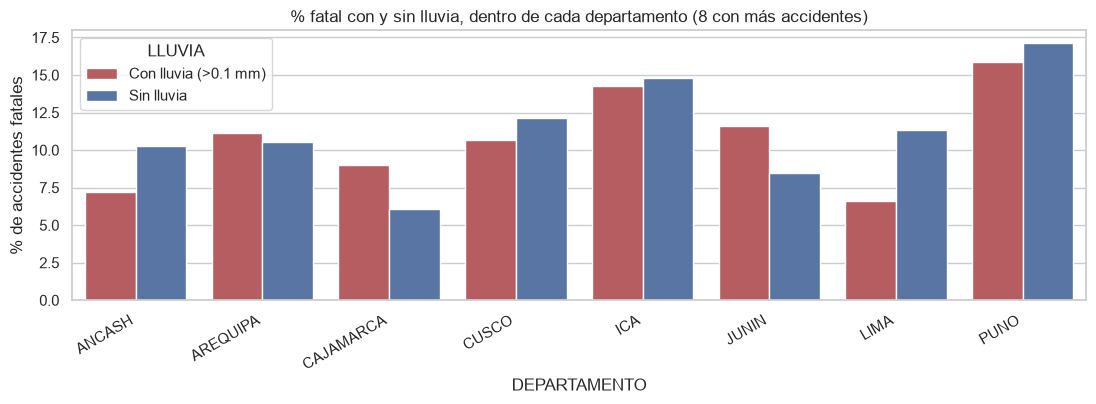

pct_fatal                            size           
LLUVIA       Con lluvia (>0.1 mm) Sin lluvia Con lluvia (>0.1 mm) Sin lluvia
DEPARTAMENTO                                                                
ANCASH                       7.20      10.29                250.0      350.0
AREQUIPA                    11.11      10.54                270.0      522.0
CAJAMARCA                    9.01       6.09                233.0      115.0
CUSCO                       10.66      12.16                272.0       74.0
ICA                         14.29      14.77                 49.0      325.0
JUNIN                       11.60       8.45                569.0      142.0
LIMA                         6.64      11.36                497.0     1056.0
PUNO                        15.88      17.11                340.0      187.0

,umbral > 0.1 mm,umbral > 0 mm
DEPARTAMENTO,,
ANCASH,-3.1,-4.4
AREQUIPA,0.6,0.9
CAJAMARCA,2.9,3.0
CUSCO,-1.5,-4.2
ICA,-0.5,-0.8
JUNIN,3.1,3.5
LIMA,-4.7,-4.3
PUNO,-1.2,-3.1


In [22]:
top = d.DEPARTAMENTO.value_counts().head(8).index
d["LLUVIA"] = np.where(d.precipitation_sum > 0.1, "Con lluvia (>0.1 mm)", "Sin lluvia")
g = (d[d.DEPARTAMENTO.isin(top)].groupby(["DEPARTAMENTO", "LLUVIA"]).ES_FATAL
     .agg(["mean", "size"]).reset_index())
g["pct_fatal"] = 100 * g["mean"]
plt.figure(figsize=(11, 4.2))
sns.barplot(data=g, x="DEPARTAMENTO", y="pct_fatal", hue="LLUVIA", palette=["#C44E52", "#4C72B0"])
plt.xticks(rotation=30, ha="right"); plt.ylabel("% de accidentes fatales")
plt.title("% fatal con y sin lluvia, dentro de cada departamento (8 con más accidentes)")
plt.tight_layout(); plt.savefig(PLOTS / "eda_07_lluvia_por_departamento.png", dpi=150); plt.show()
display(g.pivot(index="DEPARTAMENTO", columns="LLUVIA", values=["pct_fatal", "size"]).round(2))

# Sensibilidad al umbral: diferencia de % fatal (con lluvia − sin lluvia), en puntos porcentuales
dt = d[d.DEPARTAMENTO.isin(top)]
umbral = pd.DataFrame({
    f"umbral > {u} mm": dt.assign(L=dt.precipitation_sum > u).groupby(["DEPARTAMENTO", "L"]).ES_FATAL.mean()
                          .unstack().pipe(lambda x: 100 * (x[True] - x[False]))
    for u in (0.1, 0)
}).round(1)
umbral

**Hallazgo:** el signo cambia entre departamentos (sube en Junín y Cajamarca, baja en Lima y Áncash) y no depende del umbral. En Lima, los accidentes con lluvia están sobre todo en la sierra: la comparación mezcla lluvia y lugar.

### 4.4 Altitud

Variable nueva gracias a la ubicación. Solo accidentes ubicados por km. **Decisión:** rangos costa (< 500 m), valles (500–2 500), sierra (2 500–3 500) y puna (> 3 500).

,accidentes,fatales,fallecidos_por_accidente,lluvia_media_mm,pct_dias_con_lluvia,pct_fatal,ic95_inf,ic95_sup
ALTITUD,,,,,,,,
< 500 m,3015,392,0.17,1.00,24.78,13.00,11.85,14.25
500–2 500 m,1193,143,0.19,2.53,47.02,11.99,10.26,13.95
2 500–3 500 m,448,47,0.14,2.93,67.41,10.49,7.98,13.67
> 3 500 m,1846,181,0.16,3.62,74.11,9.80,8.53,11.25


Spearman altitud vs. fatal: rho=-0.0471, p=0.0001466


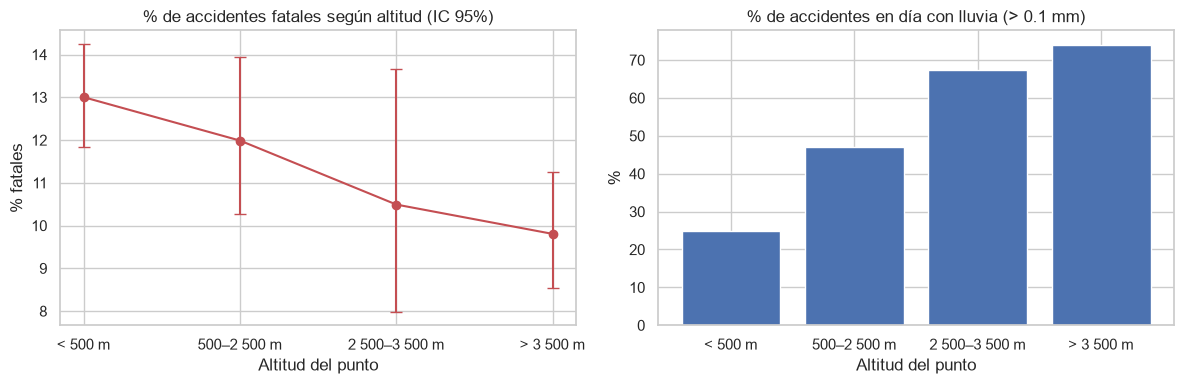

In [23]:
k = d[d.UBICACION == "km"].copy()
k["ALTITUD"] = pd.cut(k.ELEVACION, [-np.inf, 500, 2500, 3500, np.inf],
                      labels=["< 500 m", "500–2 500 m", "2 500–3 500 m", "> 3 500 m"])
alt = k.groupby("ALTITUD", observed=True).agg(accidentes=("ES_FATAL", "size"), fatales=("ES_FATAL", "sum"),
                                             fallecidos_por_accidente=("NUM_FALLECIDOS", "mean"),
                                             lluvia_media_mm=("precipitation_sum", "mean"),
                                             pct_dias_con_lluvia=("precipitation_sum", lambda x: 100 * (x > 0.1).mean()))
alt["pct_fatal"] = 100 * alt.fatales / alt.accidentes
lo, hi = wilson(alt.fatales.values, alt.accidentes.values)
alt["ic95_inf"], alt["ic95_sup"] = 100 * lo, 100 * hi
display(alt.round(2))
rho_e, p_e = stats.spearmanr(k.ELEVACION, k.ES_FATAL)
print(f"Spearman altitud vs. fatal: rho={rho_e:.4f}, p={p_e:.4g}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(alt))
ax[0].errorbar(x, alt.pct_fatal, yerr=[alt.pct_fatal - alt.ic95_inf, alt.ic95_sup - alt.pct_fatal], fmt="o-", capsize=4, color="#C44E52")
ax[0].set_xticks(x); ax[0].set_xticklabels(alt.index)
ax[0].set(title="% de accidentes fatales según altitud (IC 95%)", xlabel="Altitud del punto", ylabel="% fatales")
ax[1].bar(x, alt.pct_dias_con_lluvia, color="#4C72B0")
ax[1].set_xticks(x); ax[1].set_xticklabels(alt.index)
ax[1].set(title="% de accidentes en día con lluvia (> 0.1 mm)", xlabel="Altitud del punto", ylabel="%")
plt.tight_layout(); plt.savefig(PLOTS / "eda_11_altitud.png", dpi=150); plt.show()

**Hallazgo:** el % fatal **baja con la altitud** (13.0 % costa → 9.8 % puna) y los días con lluvia **suben** (25 % → 74 %). La asociación negativa lluvia-fatalidad es compatible con un efecto de la geografía. **Decisión:** incluir `ELEVACION` en los modelos.

### 4.5 Vista agregada (departamento-día)

**Decisión:** aquí se usa `PRECIP_CAPITAL`, porque la unidad es el departamento. Solo hay días con accidentes, así que no mide frecuencia.

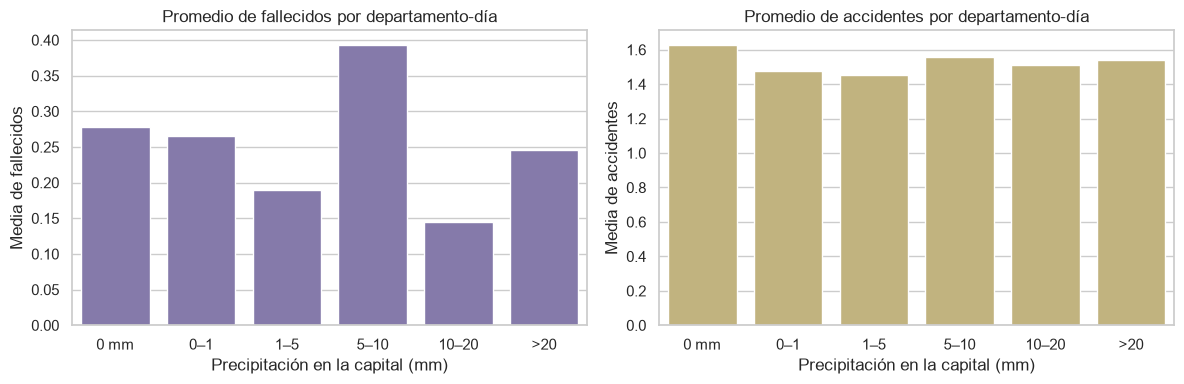

,departamento-días,fallecidos (media),fallecidos (media sin extremos),fallecidos (mediana),accidentes (media)
PRECIP_BIN,,,,,
0 mm,2569,0.279,0.246,0.0,1.630
0–1,1054,0.266,0.240,0.0,1.477
1–5,898,0.189,0.177,0.0,1.453
5–10,414,0.394,0.301,0.0,1.560
10–20,208,0.144,0.144,0.0,1.510
>20,65,0.246,0.246,0.0,1.538


In [24]:
dd = (
    d.groupby(["DEPARTAMENTO", "FECHA"])
    .agg(accidentes=("ES_FATAL", "size"), fallecidos=("NUM_FALLECIDOS", "sum"),
         max_fallecidos=("NUM_FALLECIDOS", "max"), precip=("PRECIP_CAPITAL", "first"))
    .reset_index()
)
dd["PRECIP_BIN"] = pd.cut(dd.precip, bins=BINS, labels=ETIQ)

resumen_agg = dd.groupby("PRECIP_BIN", observed=False)[["fallecidos", "accidentes"]].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=resumen_agg, x="PRECIP_BIN", y="fallecidos", ax=ax[0], color="#8172B2")
ax[0].set(title="Promedio de fallecidos por departamento-día", xlabel="Precipitación en la capital (mm)", ylabel="Media de fallecidos")
sns.barplot(data=resumen_agg, x="PRECIP_BIN", y="accidentes", ax=ax[1], color="#CCB974")
ax[1].set(title="Promedio de accidentes por departamento-día", xlabel="Precipitación en la capital (mm)", ylabel="Media de accidentes")
plt.tight_layout(); plt.savefig(PLOTS / "eda_08_agregado_dep_dia.png", dpi=150); plt.show()

# Misma vista sin los departamento-día que incluyen un accidente extremo, y con la mediana
pd.DataFrame({
    "departamento-días": dd.groupby("PRECIP_BIN", observed=True).size(),
    "fallecidos (media)": dd.groupby("PRECIP_BIN", observed=True).fallecidos.mean(),
    "fallecidos (media sin extremos)": dd[dd.max_fallecidos < 10].groupby("PRECIP_BIN", observed=True).fallecidos.mean(),
    "fallecidos (mediana)": dd.groupby("PRECIP_BIN", observed=True).fallecidos.median(),
    "accidentes (media)": dd.groupby("PRECIP_BIN", observed=True).accidentes.mean(),
}).round(3)

**Hallazgo:** los fallecidos por departamento-día no siguen un orden con la lluvia y los accidentes por día son ≈ 1.5 en todos los rangos.

### 4.6 Hallazgos del EDA

1. **Datos:** 8 110 accidentes (ene 2020 – sep 2021), 11.7 % fatales, fallecidos con sobredispersión.
2. **Ubicación:** 80.2 % ubicado por vía y km; la lluvia de la capital era un mal *proxy* (correlación 0.54).
3. **Lluvia:** no hay evidencia de que aumente la fatalidad; la asociación es débil, negativa y cambia de signo entre departamentos.
4. **Altitud:** en la sierra llueve más y los accidentes son algo menos fatales; probablemente explica el signo negativo.
5. **Variables más asociadas a la fatalidad:** modalidad (atropello), hora (madrugada), departamento y altitud.
6. **Para los modelos:** agregar `ELEVACION`, evaluar la lluvia controlando por altitud y departamento, y usar métricas para clases desbalanceadas.

**Limitaciones:** reanálisis en celdas de ~11 km; 19.8 % con lluvia de la capital; capa vial de 2014; sin datos de tráfico ni días sin accidentes; periodo de pandemia.